# Notebook 2 — Treinamento do Modelo e Definição de SLOs

## Aula 6: Monitoramento Contínuo e Data SLOs em Produção

### Objetivos

1. Treinar um modelo de classificação de risco de crédito (GBM) nos dados de referência.
2. Realizar validação cruzada e ajuste de hiperparâmetros.
3. Definir **Data SLOs** (acurácia mínima, drift máximo, qualidade de dados).
4. Avaliar performance baseline e calibração (Brier Score).

### Conexão com o Documento 04

> *"Service Level Objectives (SLOs) são as metas ou faixas aceitáveis para
> os indicadores. Em outras palavras, um SLO é um compromisso interno de
> que o sistema manterá o SLI dentro de certo patamar."*
> — DOCUMENTO_AULA_6.md, seção 'SLIs e Data SLOs em ML'

### Vídeos Relacionados

- **Vídeo 6.2**: Definição de Data SLOs, Error Budget, dashboards Grafana/Prometheus
- **Vídeo 6.3**: Pipeline de monitoramento com SLOs em Python

In [1]:
# Imports
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Adicionar diretório pai ao path
sys.path.insert(0, str(Path.cwd().parent))

from src.data_preprocessing import DataPreprocessor
from src.training import CreditModelTrainer
from src.evaluation import ModelEvaluator, calculate_brier_score
from src.utils import save_model, save_metrics, setup_logging

setup_logging()

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

%matplotlib inline

## 1. Preparação dos Dados

Carregamos o dataset e separamos os dados de **referência** (treino)
dos dados de **produção** (que serão usados para monitoramento no Notebook 3).

Conforme o DOCUMENTO_AULA_6.md:
> *"O modelo de crédito gera previsões y_pred diariamente, e temos os
> rótulos reais y_true dos últimos dias. Queremos que a acurácia se
> mantenha acima de 85%."*

In [2]:
# Carregar e preparar dados
preprocessor = DataPreprocessor(random_state=42)

try:
    data = preprocessor.load_data()
except FileNotFoundError:
    DataPreprocessor.generate_dataset()
    data = preprocessor.load_data()

# Separar referência e produção
df_ref, df_prod = preprocessor.split_reference_production(data)

# Limpar dados de referência
df_ref_clean = preprocessor.clean_data(df_ref)

# Preparar features e target
X_ref, y_ref = preprocessor.prepare_features(df_ref_clean)

print(f"Features de referência: {X_ref.shape}")
print(f"Target: {y_ref.value_counts().to_dict()}")

Dados carregados: 10000 amostras, 12 colunas
Referência: 5000 | Produção: 5000
  idade: 20 missings preenchidos com mediana (35.13)
  renda_mensal: 24 missings preenchidos com mediana (7983.22)
  score_credito: 27 missings preenchidos com mediana (601.38)
  tempo_emprego: 33 missings preenchidos com mediana (3.59)
  saldo_conta: 33 missings preenchidos com mediana (2915.19)
Features de referência: (5000, 10)
Target: {0: 4875, 1: 125}


## 2. Definição dos Data SLOs

Definimos os SLOs que serão monitorados em produção, baseados nos
conceitos da seção 'SLIs e Data SLOs em ML' do DOCUMENTO_AULA_6.md.

| SLO | Indicador (SLI) | Threshold | Justificativa |
|-----|-----------------|-----------|---------------|
| Acurácia mínima | accuracy_score | ≥ 85% | Snippet 1 do doc 04 |
| Drift máximo (KS) | p-value KS test | ≥ 0.05 | Snippet 2 do doc 04 |
| Qualidade dados | missing rate | ≤ 1% | Snippet 3 do doc 04 |
| Drift máximo (PSI) | PSI | < 0.25 | Fórmula PSI do doc 04 |

O **Error Budget** é a margem de tolerância entre o SLO e o estado atual.
Se o error budget se esgota, ações corretivas são necessárias.

In [3]:
# Definição formal dos SLOs
# Conforme seção 'SLIs e Data SLOs em ML' do DOCUMENTO_AULA_6.md
SLO_CONFIG = {
    "accuracy_slo": 0.85,            # Acurácia mínima (85%)
    "drift_p_value_threshold": 0.05,  # p-valor mínimo para teste KS
    "missing_rate_slo": 0.01,         # Taxa máxima de missings (1%)
    "psi_threshold": 0.25,            # PSI máximo para drift severo
}

print("Data SLOs Definidos:")
print("=" * 50)
for slo_name, threshold in SLO_CONFIG.items():
    print(f"  {slo_name}: {threshold}")

Data SLOs Definidos:
  accuracy_slo: 0.85
  drift_p_value_threshold: 0.05
  missing_rate_slo: 0.01
  psi_threshold: 0.25


## 3. Treinamento do Modelo

Treinamos um **Gradient Boosting Classifier** nos dados de referência,
conforme cenário da fintech descrito no DOCUMENTO_AULA_6.md.

O modelo treinado aqui será monitorado no Notebook 3 usando o
`MonitoringPipeline` e `SLOMonitor`.

In [4]:
# Dividir dados de referência em treino/teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_ref, y_ref, test_size=0.2, random_state=42, stratify=y_ref
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")

Treino: 4000 amostras
Teste:  1000 amostras


In [5]:
# Treinar modelo GBM
trainer = CreditModelTrainer(model_type="gbm", random_state=42)
model = trainer.train_model(X_train, y_train)

# Performance no treino e teste
train_acc = trainer.score(X_train, y_train)
test_acc = trainer.score(X_test, y_test)

print(f"\nAcurácia treino: {train_acc:.4f}")
print(f"Acurácia teste:  {test_acc:.4f}")
print(f"SLO de acurácia: {SLO_CONFIG['accuracy_slo']:.4f}")
print(f"\n{'✅ SLO atendido!' if test_acc >= SLO_CONFIG['accuracy_slo'] else '❌ SLO VIOLADO!'}")

2026-06-09 16:36:37 [INFO] src.training: Modelo treinado (gbm). Acurácia treino: 0.9990

Acurácia treino: 0.9990
Acurácia teste:  0.9740
SLO de acurácia: 0.8500

✅ SLO atendido!


## 4. Validação Cruzada

Avaliamos a robustez do modelo com validação cruzada (5-fold),
conforme boas práticas de MLOps (Breck et al., 2017).

In [6]:
# Validação cruzada
cv_scores = trainer.cross_validate(X_ref, y_ref, cv=5)

print(f"\nScores por fold: {np.round(cv_scores, 4)}")
print(f"Média: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Mínimo: {cv_scores.min():.4f}")
print(f"\nError Budget: {cv_scores.mean() - SLO_CONFIG['accuracy_slo']:.4f} "
      f"(margem acima do SLO)")

2026-06-09 16:37:02 [INFO] src.training: Validação cruzada (5 folds): média=0.9710 ± 0.0013

Scores por fold: [0.969 0.972 0.972 0.972 0.97 ]
Média: 0.9710 ± 0.0013
Mínimo: 0.9690

Error Budget: 0.1210 (margem acima do SLO)


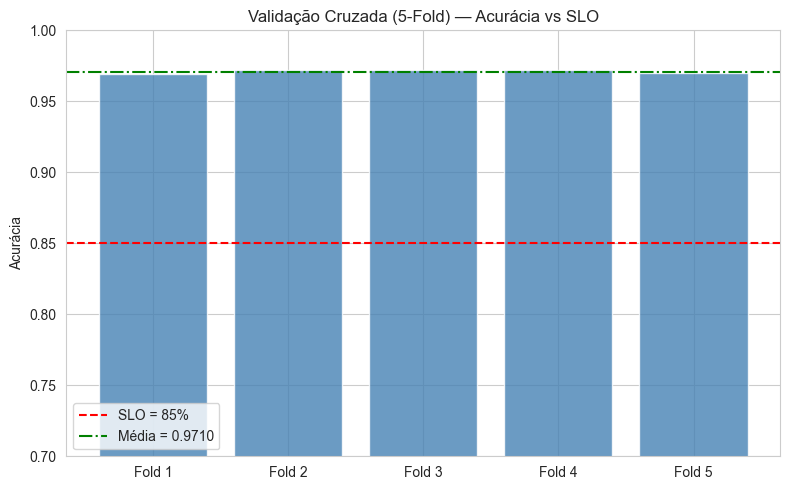

In [7]:
# Visualizar scores de CV
fig, ax = plt.subplots(figsize=(8, 5))
folds = [f"Fold {i+1}" for i in range(len(cv_scores))]
ax.bar(folds, cv_scores, color="steelblue", alpha=0.8)
ax.axhline(y=SLO_CONFIG["accuracy_slo"], color="red", linestyle="--",
           label=f"SLO = {SLO_CONFIG['accuracy_slo']:.0%}")
ax.axhline(y=cv_scores.mean(), color="green", linestyle="-.",
           label=f"Média = {cv_scores.mean():.4f}")
ax.set_ylabel("Acurácia")
ax.set_title("Validação Cruzada (5-Fold) — Acurácia vs SLO")
ax.legend()
ax.set_ylim(0.7, 1.0)
plt.tight_layout()
plt.savefig("../outputs/figures/cross_validation.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Métricas de Avaliação e Brier Score

Calculamos as métricas de avaliação incluindo o **Brier Score** para
calibração probabilística, conforme a fórmula do DOCUMENTO_AULA_6.md:

$$
BS = \frac{1}{N} \sum_{i=1}^{N} (p_i - y_i)^2
$$

> *"O Brier Score mede o erro quadrático médio das previsões probabilísticas
> e indica o quão bem calibrado o modelo está (quanto menor, melhor)."*
> — DOCUMENTO_AULA_6.md, seção 'SLIs e Data SLOs em ML'

In [8]:
# Calcular métricas completas nos dados de teste (referência)
evaluator = ModelEvaluator(figures_dir="../outputs/figures")

y_pred_test = trainer.predict(X_test)
y_proba_test = trainer.predict_proba(X_test)[:, 1]

metrics_ref = evaluator.calculate_metrics(y_test, y_pred_test, y_proba_test)

print("Métricas Baseline (Dados de Referência)")
print("=" * 50)
for name, value in metrics_ref.items():
    print(f"  {name}: {value:.4f}")

# Brier Score (calibração)
brier = calculate_brier_score(y_test.values, y_proba_test)
print(f"\nBrier Score: {brier:.4f} (quanto menor, melhor calibração)")

2026-06-09 16:37:04 [INFO] src.evaluation: Métricas calculadas: {'accuracy': 0.974, 'precision': 0.0, 'recall': 0.0, 'f1_score': 0.0, 'roc_auc': 0.6256820512820512, 'brier_score': 0.02568507803741843}
Métricas Baseline (Dados de Referência)
  accuracy: 0.9740
  precision: 0.0000
  recall: 0.0000
  f1_score: 0.0000
  roc_auc: 0.6257
  brier_score: 0.0257

Brier Score: 0.0257 (quanto menor, melhor calibração)


## 6. Visualizações do Modelo

Geramos as visualizações padrão de avaliação: Matriz de Confusão,
Curva ROC e Curva de Calibração, conforme discutido na seção
'SLIs e Data SLOs em ML' do DOCUMENTO_AULA_6.md.

> *"Ovadia et al. (2019) constataram que métodos modernos sofrem redução
> de acerto e ficam super ou sub-confiantes quando expostos a dados
> cuja distribuição diverge daquela original."*

2026-06-09 16:37:04 [INFO] src.evaluation: Figura salva: ..\outputs\figures\confusion_matrix_baseline.png


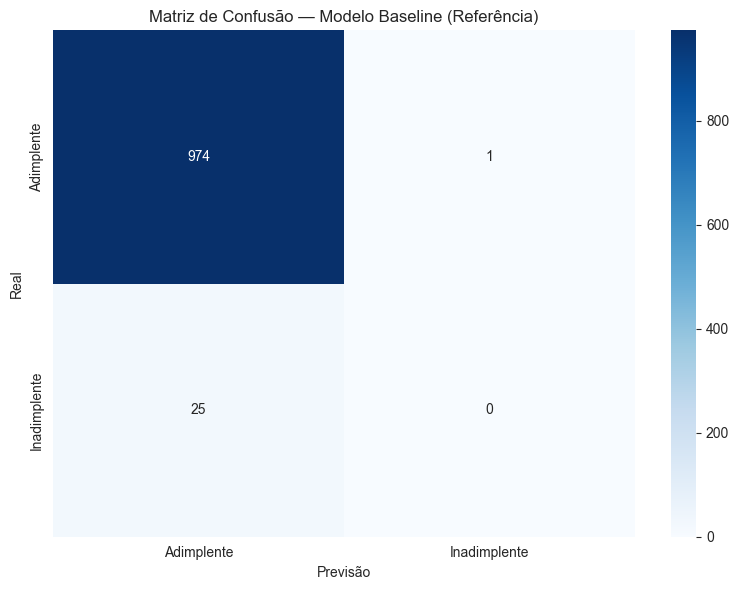

In [9]:
# Matriz de Confusão
fig_cm = evaluator.plot_confusion_matrix(
    y_test.values, y_pred_test,
    title="Matriz de Confusão — Modelo Baseline (Referência)",
    filename="confusion_matrix_baseline.png",
)
plt.show()

2026-06-09 16:37:05 [INFO] src.evaluation: Figura salva: ..\outputs\figures\roc_curve_baseline.png


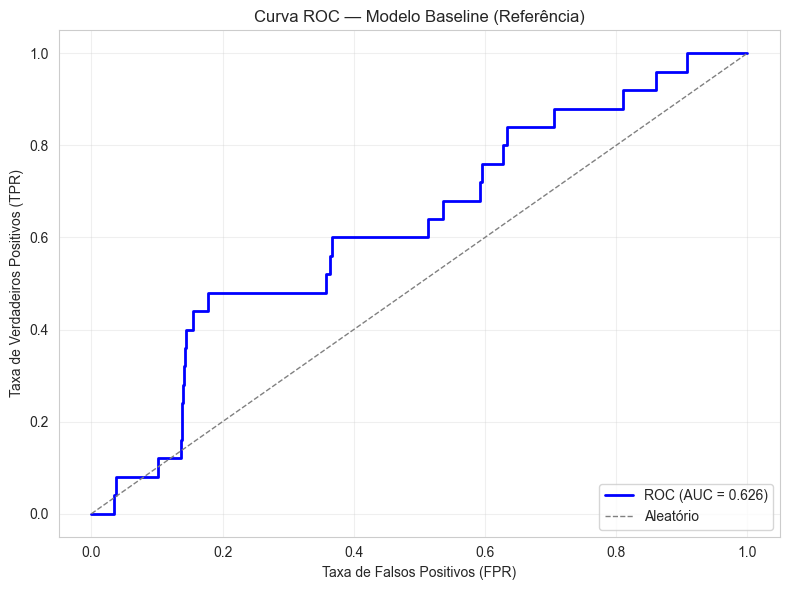

In [10]:
# Curva ROC
fig_roc = evaluator.plot_roc_curve(
    y_test.values, y_proba_test,
    title="Curva ROC — Modelo Baseline (Referência)",
    filename="roc_curve_baseline.png",
)
plt.show()

2026-06-09 16:37:07 [INFO] src.evaluation: Figura salva: ..\outputs\figures\calibration_curve_baseline.png


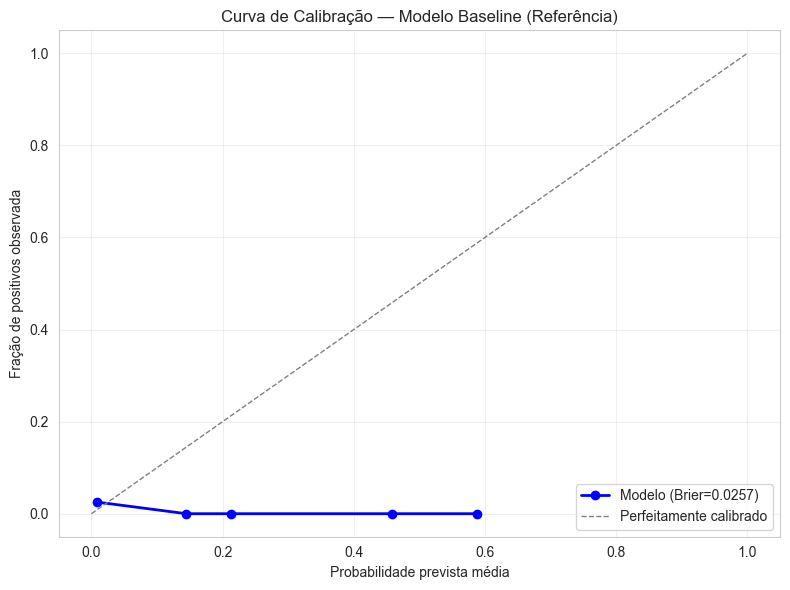

In [11]:
# Curva de Calibração
# Conforme Ovadia et al. (2019): calibração se deteriora sob dataset shift
fig_cal = evaluator.plot_calibration_curve(
    y_test.values, y_proba_test,
    title="Curva de Calibração — Modelo Baseline (Referência)",
    filename="calibration_curve_baseline.png",
)
plt.show()

## 7. Importância das Features

Verificamos quais features o modelo considera mais relevantes.
Isso ajuda a priorizar o monitoramento de drift nas features
mais impactantes para a decisão de crédito.

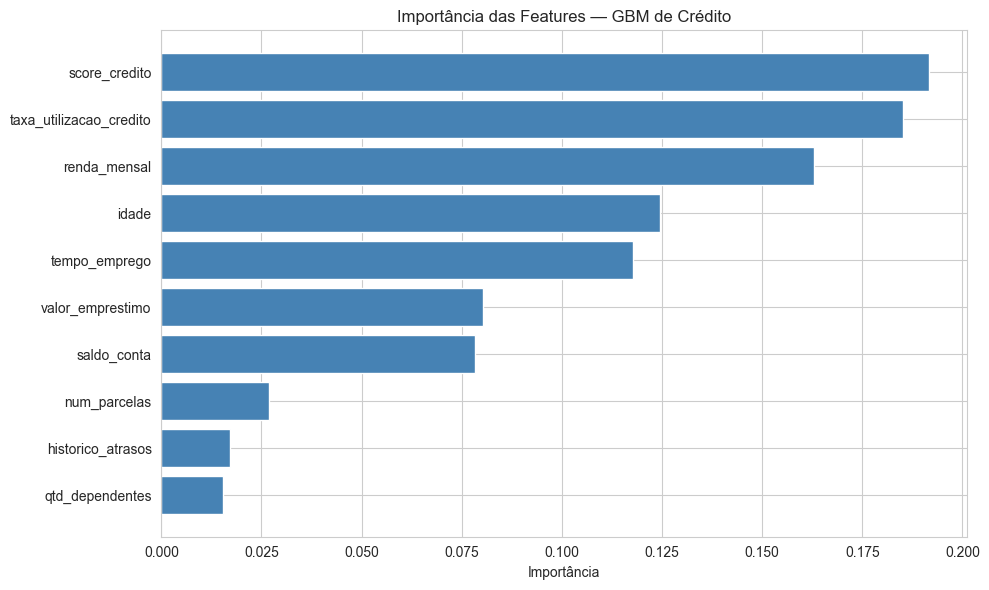

In [12]:
# Importância das features (do classificador GBM dentro do pipeline)
classifier = trainer.model.named_steps["classifier"]
importances = classifier.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importância": importances,
}).sort_values("Importância", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df["Feature"], importance_df["Importância"], color="steelblue")
ax.set_xlabel("Importância")
ax.set_title("Importância das Features — GBM de Crédito")
plt.tight_layout()
plt.savefig("../outputs/figures/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Salvar Modelo e Métricas Baseline

Salvamos o modelo treinado e as métricas baseline para uso
no pipeline de monitoramento (Notebook 3).

In [13]:
# Salvar modelo
model_path = "../outputs/models/credit_model.joblib"
save_model(trainer.model, model_path)

# Salvar métricas baseline
baseline_metrics = {
    "dataset": "referência",
    "model_type": "gbm",
    "metrics": metrics_ref,
    "brier_score": brier,
    "cv_mean": float(cv_scores.mean()),
    "cv_std": float(cv_scores.std()),
    "slo_config": SLO_CONFIG,
}
save_metrics(baseline_metrics, "../outputs/logs/baseline_metrics.json")

print("Modelo e métricas baseline salvos com sucesso!")

2026-06-09 16:37:09 [INFO] src.utils: Modelo salvo: ..\outputs\models\credit_model.joblib
2026-06-09 16:37:09 [INFO] src.utils: Métricas salvas: ..\outputs\logs\baseline_metrics.json
Modelo e métricas baseline salvos com sucesso!


## Resumo

### O que aprendemos neste notebook:

1. **Modelo GBM** treinado nos dados de referência com acurácia acima do SLO de 85%.

2. **Data SLOs definidos**: acurácia ≥ 85%, drift KS p-value ≥ 0.05,
   missing rate ≤ 1%, PSI < 0.25.

3. **Validação cruzada** confirma robustez do modelo (5-fold).

4. **Brier Score** avalia a calibração probabilística do modelo,
   conforme fórmula do DOCUMENTO_AULA_6.md.

5. **Error Budget**: margem entre performance atual e SLO,
   conforme conceito discutido no Vídeo 6.2.

### Próximo notebook

No **Notebook 03 (Avaliação)**, aplicaremos o modelo nos dados de produção
e executaremos o pipeline completo de monitoramento com verificação de
SLOs (acurácia, drift, qualidade).